# Load library

In [13]:
import sys
from os.path import exists

# this is the repository I pulled/downloaded from github: 
CONGA_PATH = r"C:\Users\andre\conga"
# confirm that it's the right level directory (since the repo and library have the same name)
assert exists(CONGA_PATH+'/README.md')
sys.path.append(CONGA_PATH)
import scanpy as sc
import conga
import joblib
import pandas as pd
import scvi
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\andre\revision")

In [ ]:
# import ipympl
# import matplotlib.collections as mcoll
# from adjustText import adjust_text
# import matplotlib.patheffects as PathEffects

# class DraggableText:
#     def __init__(self, text):
#         self.text = text
#         text.set_picker(True)  # enable pick events on the text
#         self.press = None
#         # connect pick event
#         text.figure.canvas.mpl_connect('pick_event', self.on_pick)

#     def on_pick(self, event):
#         if event.artist is not self.text: return
#         x0, y0 = self.text.get_position()
#         xpress, ypress = event.mouseevent.xdata, event.mouseevent.ydata
#         self.press = (x0, y0, xpress, ypress)
#         # connect motion and release
#         self.cidmotion = self.text.figure.canvas.mpl_connect(
#             'motion_notify_event', self.on_motion)
#         self.cidrelease = self.text.figure.canvas.mpl_connect(
#             'button_release_event', self.on_release)

#     def on_motion(self, event):
#         if self.press is None or event.xdata is None: return
#         x0, y0, xpress, ypress = self.press
#         dx, dy = event.xdata - xpress, event.ydata - ypress
#         self.text.set_position((x0 + dx, y0 + dy))
#         self.text.figure.canvas.draw_idle()

#     def on_release(self, event):
#         # disconnect the motion/release callbacks
#         self.text.figure.canvas.mpl_disconnect(self.cidmotion)
#         self.text.figure.canvas.mpl_disconnect(self.cidrelease)
#         self.press = None

In [2]:
# Nice palette generated by @xuancong84 and @Greg0ry on stack overflow
import math
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.cm import hsv


def generate_colormap(number_of_distinct_colors: int = 80):
    if number_of_distinct_colors == 0:
        number_of_distinct_colors = 80

    number_of_shades = 7
    number_of_distinct_colors_with_multiply_of_shades = int(math.ceil(number_of_distinct_colors / number_of_shades) * number_of_shades)

    # Create an array with uniformly drawn floats taken from <0, 1) partition
    linearly_distributed_nums = np.arange(number_of_distinct_colors_with_multiply_of_shades) / number_of_distinct_colors_with_multiply_of_shades

    # We are going to reorganise monotonically growing numbers in such way that there will be single array with saw-like pattern
    #     but each saw tooth is slightly higher than the one before
    # First divide linearly_distributed_nums into number_of_shades sub-arrays containing linearly distributed numbers
    arr_by_shade_rows = linearly_distributed_nums.reshape(number_of_shades, number_of_distinct_colors_with_multiply_of_shades // number_of_shades)

    # Transpose the above matrix (columns become rows) - as a result each row contains saw tooth with values slightly higher than row above
    arr_by_shade_columns = arr_by_shade_rows.T

    # Keep number of saw teeth for later
    number_of_partitions = arr_by_shade_columns.shape[0]

    # Flatten the above matrix - join each row into single array
    nums_distributed_like_rising_saw = arr_by_shade_columns.reshape(-1)

    # HSV colour map is cyclic (https://matplotlib.org/tutorials/colors/colormaps.html#cyclic), we'll use this property
    initial_cm = hsv(nums_distributed_like_rising_saw)

    lower_partitions_half = number_of_partitions // 2
    upper_partitions_half = number_of_partitions - lower_partitions_half

    # Modify lower half in such way that colours towards beginning of partition are darker
    # First colours are affected more, colours closer to the middle are affected less
    lower_half = lower_partitions_half * number_of_shades
    for i in range(3):
        initial_cm[0:lower_half, i] *= np.arange(0.2, 1, 0.8/lower_half)

    # Modify second half in such way that colours towards end of partition are less intense and brighter
    # Colours closer to the middle are affected less, colours closer to the end are affected more
    for i in range(3):
        for j in range(upper_partitions_half):
            modifier = np.ones(number_of_shades) - initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i]
            modifier = j * modifier / upper_partitions_half
            initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i] += modifier

    return ListedColormap(initial_cm)

(35, 4)


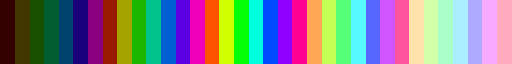

In [3]:
cmap_30=generate_colormap(5*6)
print(cmap_30.colors.shape)
cmap_30

In [4]:
clones_file = 'gut_liver_TRM_clones_without0.tsv'
organism = 'human'
outfile_prefix = 'conga_output_gut_liver_TRM' 

In [17]:
all_nbrs = joblib.load('0813_all_nbrs.pkl')
color_dict_30 = joblib.load('color_dict_30.pkl')
GEX_color_dict = joblib.load('0813_GEX_color_dict.pkl')
nbr_fracs = [0.01, 0.1]
nbr_frac_for_nndists = 0.01

In [6]:
# adata_ab = sc.read_h5ad('250723_gut_liver_TRM_adata_abTCR_conga.h5ad')
adata_ab = sc.read_h5ad('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [7]:
clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values
cmap = plt.get_cmap('tab20')
# colors = adata_ab.obs['celltype_colorcode']
colors = [cmap_30.colors[34-x] for x in clusters_gex_num]
GEX_color_array = colors
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold','axes.linewidth':2})
adata_ab.obs['gex_colors'] = GEX_color_array

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\4288984531.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values


### prepare data to meet conga's standard

In [12]:
adata = sc.read_h5ad(r"D:\Trapecar\250307_gut_liver_blood_ultimate_annotated.h5ad")

In [13]:
adata.obs.columns

Index(['has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a',
       'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes',
       'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff',
       'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type',
       'activation', 'tissue', 'general subtype', 'celltype',
       'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation',
       'major celltype', 'major general subtype', 'Donor ID',
       'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation',
       'cluster+celltype w/ activation',
       'tissue+cluster+celltype w/ activation', 'act_score',
       'donor+tissue+celltype w/ activation'],
      dtype='object')

In [14]:
adata.obs['va'] = adata.obs['TRAV']
adata.obs['ja'] = adata.obs['TRAJ'] 
adata.obs['vb'] = adata.obs['TRBV'] 
adata.obs['jb'] = adata.obs['TRBJ'] 

In [15]:
adata_TCR = adata[adata.obs['chain_pairing'].isin(["single pair", "extra VJ","extra VDJ","two full chains"]),:]

In [16]:
adata_ab = adata_TCR[adata_TCR.obs['general type'].isin(['TCRab CD4','TCRab CD8aa','TCRab CD8ab']),:]

In [17]:
adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)

C:\Users\andre\AppData\Local\Temp\ipykernel_14544\3965735778.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)


#### prepare for the TCRdist

In [18]:
clone_df = adata_ab.obs[[ 'batch','TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3a', 'cdr3b','clone_code']]

In [86]:
clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')
clone_counts[['TRAV','TRBV','cdr3a','cdr3b']] = clone_counts['clone_code'].str.split(' ', expand=True)

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\2577822773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')


In [82]:
clone_df.groupby(['batch', 'clone_code'])['TRAJ'].apply(lambda x: len(set(x))).sort_values(ascending=False)
#Just to confirm Js are unique to our clonotype strategy

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\2966889109.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_df.groupby(['batch', 'clone_code'])['TRAJ'].apply(lambda x: len(set(x))).sort_values(ascending=False)


batch  clone_code                                      
5      TRAV9-2 TRBV9 CALSPYGGATNKLIF CASSVGTGGPNEQFF       1.0
3      TRAV1-1 TRBV10-2 CAGDNYGQNFVF CASRAGGVTEAFF         1.0
       TRAV1-1 TRBV10-2 CAVRDQLPAGKSTF CASRGGGGNNEQFF      1.0
       TRAV1-1 TRBV10-3 CAGGGSAAGNKLTF CAISERPGTENEKLFF    1.0
       TRAV1-1 TRBV10-3 CAGMDSNYQLIW CAISDDRGHRNYGYTF      1.0
                                                          ... 
5      TRAV9-2 TRBV9 CALSPYNFNKFYF CASSVEVVPHEQYF          NaN
       TRAV9-2 TRBV9 CALSSNQAGTALIF CASSMDRGHNEQFF         NaN
       TRAV9-2 TRBV9 CALSTLDSSYKLIF CASSVEGSGGPNIQYF       NaN
       TRAV9-2 TRBV9 CALYTGGFKTIF CASSVSGLAGGSYNEQFF       NaN
       TRAV9-2 TRBV9 CASETSGSRLTF CASSVGRTANIQYF           NaN
Name: TRAJ, Length: 56421, dtype: float64

In [93]:
Jmap = clone_df[['TRAJ','TRBJ','clone_code']].drop_duplicates()
Jmap = Jmap.set_index('clone_code')
Jmap_adict = Jmap['TRAJ'].to_dict()
Jmap_bdict = Jmap['TRBJ'].to_dict()

In [94]:
clone_counts['ja_gene'] =clone_counts['clone_code'].replace(Jmap_adict)
clone_counts['jb_gene'] =clone_counts['clone_code'].replace(Jmap_bdict)

In [95]:
clone_counts

,batch,clone_code,clone_size,TRAV,TRBV,cdr3a,cdr3b,ja_gene,jb_gene
0,3,TRAV1-1 TRBV10-2 CAGDNYGQNFVF CASRAGGVTEAFF,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF,TRAJ26,TRBJ1-1
1,3,TRAV1-1 TRBV10-2 CAVRDQLPAGKSTF CASRGGGGNNEQFF,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF,TRAJ27,TRBJ2-1
2,3,TRAV1-1 TRBV10-2 CAVREGSSNTGKLIF CASSDPSGAKEETQYF,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF,TRAJ37,TRBJ2-5
3,3,TRAV1-1 TRBV10-3 CAGGGSAAGNKLTF CAISERPGTENEKLFF,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF,TRAJ17,TRBJ1-4
4,3,TRAV1-1 TRBV10-3 CAGMDSNYQLIW CAISDDRGHRNYGYTF,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF,TRAJ33,TRBJ1-2
...,...,...,...,...,...,...,...,...,...
56416,5,TRAV9-2 TRBV9 CALSPYNFNKFYF CASSVEVVPHEQYF,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF,TRAJ21,TRBJ2-7
56417,5,TRAV9-2 TRBV9 CALSSNQAGTALIF CASSMDRGHNEQFF,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF,TRAJ15,TRBJ2-1
56418,5,TRAV9-2 TRBV9 CALSTLDSSYKLIF CASSVEGSGGPNIQYF,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF,TRAJ12,TRBJ2-4
56419,5,TRAV9-2 TRBV9 CALYTGGFKTIF CASSVSGLAGGSYNEQFF,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF,TRAJ9,TRBJ2-1


In [51]:
clone_replace_dict = clone_counts['clone_code'].drop_duplicates().reset_index().set_index('clone_code')['index'].to_dict()

In [96]:
clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\3147651609.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)


In [ ]:
clone_counts['clone_code'] = 'clonotype'+clone_counts['clone_code'].astype(str).map(str)

In [103]:
clone_counts = clone_counts.rename(columns = {'batch':'subject',
                                              'clone_code':'clone_id',
                                              'TRAV':'va_gene',
                                              'TRBV':'vb_gene',
                                              'TRAJ':'ja_gene',
                                              'TRBJ':'jb_gene'})

In [108]:
clone_counts

,subject,clone_id,clone_size,va_gene,vb_gene,cdr3a,cdr3b,ja_gene,jb_gene
0,3,clonotype0,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF,TRAJ26,TRBJ1-1
1,3,clonotype1,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF,TRAJ27,TRBJ2-1
2,3,clonotype2,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF,TRAJ37,TRBJ2-5
3,3,clonotype3,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF,TRAJ17,TRBJ1-4
4,3,clonotype4,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF,TRAJ33,TRBJ1-2
...,...,...,...,...,...,...,...,...,...
56416,5,clonotype18802,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF,TRAJ21,TRBJ2-7
56417,5,clonotype18803,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF,TRAJ15,TRBJ2-1
56418,5,clonotype18804,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF,TRAJ12,TRBJ2-4
56419,5,clonotype18805,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF,TRAJ9,TRBJ2-1


In [109]:
clone_counts.to_csv('gut_liver_TRM_clones_with0.tsv',sep = '\t')

In [117]:
clone_counts_clean = clone_counts[clone_counts['clone_size']>0]

# we don't know such information from 10X. Default to *01 to obtain the clustering result
for col in ['va_gene','vb_gene','ja_gene','jb_gene']:
    clone_counts_clean[col] = clone_counts_clean[col].apply(lambda x: x+'*01')
clone_counts_clean
clone_counts_clean.to_csv(clones_file,sep = '\t')

C:\Users\andre\AppData\Local\Temp\ipykernel_12256\85995449.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clone_counts_clean[col] = clone_counts_clean[col].apply(lambda x: x+'*01')


In [118]:
conga.preprocess.make_tcrdist_kernel_pcs_file_from_clones_file(clones_file, organism)

compute tcrdist distance matrix for 18807 clonotypes
Using Python TCRdist calculator. Consider compiling C++ calculator for faster perfomance.
running KernelPCA with None kernel distance matrix shape= (18807, 18807) D.max()= 901.0 force_Dmax= None
writing TCRdist kernel PCs to outfile: gut_liver_TRM_clones_without0_AB.dist_50_kpcs


### retrive mapping dict

In [19]:
tcr_pca = pd.read_csv('gut_liver_TRM_clones_without0_AB.dist_50_kpcs',sep = ' ',index_col = 1,header = None)
del tcr_pca[0]
tcr_pca.index.names = ['clonotypes']
tcr_pca.columns = ['PC_'+str(i-2) for i in tcr_pca.columns]

In [20]:
clone_counts= pd.read_csv('gut_liver_TRM_clones_with0.tsv',sep = '\t',index_col = 0)
clone_counts_clean = pd.read_csv(clones_file,sep = '\t',index_col = 0)

In [21]:
temp_dict_df = clone_counts[clone_counts['clone_size']>0][['clone_id','va_gene','vb_gene','cdr3a','cdr3b']]
temp_dict_df['clone_code'] = temp_dict_df['va_gene'].astype(str).map(str) + ' ' + temp_dict_df['vb_gene'].astype(str).map(str) + ' ' + temp_dict_df['cdr3a'].astype(str).map(str) + ' ' + temp_dict_df['cdr3b'].astype(str).map(str)
clone_replace_dict = temp_dict_df[['clone_id','clone_code']].set_index('clone_code').sort_index()['clone_id'].to_dict()
# clone_counts[['va_gene','vb_gene','cdr3a','cdr3b']]

In [ ]:
# adata_ab.write('250721_gut_liver_TRM_adata_abTCR.h5ad')

### organize adata_ab

#### basic preprocessing

In [22]:
adata_ab.uns['organism'] = organism

In [23]:
adata_ab.obs['subject_id'] = adata_ab.obs['batch']

In [24]:
adata_ab.obs['clone_id'] = adata_ab.obs['clone_code']
adata_ab.obs['clone_id'] = adata_ab.obs['clone_id'].replace(clone_replace_dict)
# adata_ab.obs['clone_id'] = 'clonotype' + adata_ab.obs['clone_id'].astype(str).map(str)

In [26]:
adata_ab.obs['clone_id']

AAACCTGAGCGCCTCA-1-3-PB     clonotype16056
AAACCTGAGGCAAAGA-1-3-PB     clonotype15288
AAACCTGAGTTATCGC-1-3-PB      clonotype5937
AAACCTGCAAGCGATG-1-3-PB      clonotype9202
AAACCTGGTTACGTCA-1-3-PB      clonotype4064
                                 ...      
TTTGTCAAGAACTGTA-1-5-IEL    clonotype10944
TTTGTCAAGGGAGTAA-1-5-IEL    clonotype12287
TTTGTCAAGTTGTCGT-1-5-IEL    clonotype10734
TTTGTCACAATGACCT-1-5-IEL     clonotype3531
TTTGTCACATCGATTG-1-5-IEL     clonotype9388
Name: clone_id, Length: 26297, dtype: object

In [28]:
adata_ab.obsm['X_pca_tcr'] = tcr_pca.loc[adata_ab.obs['clone_id'],:].values

In [29]:
for col in ['va','vb','ja','jb']:
    adata_ab.obs[col] = adata_ab.obs[col].apply(lambda x: x+'*01')

In [35]:
nucseq= pd.read_csv(r'C:\Users\andre\Documents\GitHub\gut-liver-TRM\Revision\refined_id_mapping\nucseq.csv',index_col = 0)

In [37]:
adata_ab.obs['cdr3a_nucseq'] = nucseq['cdr3a_nucseq']
adata_ab.obs['cdr3b_nucseq'] = nucseq['cdr3b_nucseq']

In [39]:
adata_ab.X = adata_ab.layers['counts']

In [40]:
# adata_ab.obsm['X_pca_gex'] = adata_ab.obsm['X_pca']
# adata_ab.obsm['X_gex_2d'] = adata_ab.obsm['X_umap']
adata_ab.obs['clusters_gex'] = adata_ab.obs['tissue+celltype']
# adata_ab.obs.groupby('tissue+celltype').ngroup().astype('str')
adata_ab.obs['clusters_gex'].values.categories.shape

(29,)

In [41]:
# adata_ab.write('250721_gut_liver_TRM_adata_abTCR_conga_input.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga_input.h5ad')
adata_ab.write('250813_gut_liver_TRM_adata_abTCR_conga_input.h5ad')

In [43]:
adata_ab = conga.preprocess.filter_and_scale( 
    adata_ab, 
    min_genes_per_cell=200,
    max_genes_per_cell=6000,
    max_percent_mito=0.5,
)

filtered out 0 cells with more than 6000 genes
filtered out 0 cells with more than 0.5 percent mito
unable to find feature_types varname
Index(['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'AAAS', 'AACS', 'AAGAB', 'AAK1',
       'AAMDC', 'AAMP',
       ...
       'ZUP1', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', length=15553)


c:\users\andre\conga\conga\preprocess.py:548: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\preprocessing\_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


excluding 117 TR genes (85 variable)
excluding 11 sexlinked genes
total of 1215 variable genes (26297, 15553)
Normalize and logging matrix...
unable to find feature_types varname
Index(['A2M', 'ABCA1', 'ABCB1', 'ABCC4', 'ABI3', 'AC002331.1', 'AC004832.6',
       'AC005083.1', 'AC007384.1', 'AC007952.4',
       ...
       'ZFP36', 'ZFP36L1', 'ZFP36L2', 'ZNF165', 'ZNF267', 'ZNF331', 'ZNF683',
       'ZNF80', 'ZSWIM6', 'ZYX'],
      dtype='object', length=1215)
normalize_and_log_the_raw_matrix: adata.raw.X.max()=  2567.0


#### after preprocessing, starting from here

In [57]:
adata_ab = conga.preprocess.reduce_to_single_cell_per_clone(adata_ab)

adata_ab

compute pca to find rep cell for each clone (26297, 1215)
retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present
num_clones: 18807
normalize_and_log_the_raw_matrix:: matrix is already logged
choose representative cell for clone: 0 18807 (26297, 1215)
choose representative cell for clone: 1000 18807 (26297, 1215)
choose representative cell for clone: 2000 18807 (26297, 1215)
choose representative cell for clone: 3000 18807 (26297, 1215)
choose representative cell for clone: 4000 18807 (26297, 1215)
choose representative cell for clone: 5000 18807 (26297, 1215)
choose representative cell for clone: 6000 18807 (26297, 1215)
choose representative cell for clone: 7000 18807 (26297, 1215)
choose representative cell for clone: 8000 18807 (26297, 1215)
choose representative cell for clone: 9000 18807 (26297, 1215)
choose representative cell for clone: 10000 18807 (26297, 1215)
choose representative cell for clone: 11000 18807 (26297, 1215)
choose representative 

c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present


AnnData object with n_obs × n_vars = 18807 × 1215
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'va', 'ja', 'vb', 'jb', 'clone_code', 'subject_id', 'clone_id', 'cdr3a_nucseq', 'cdr3b_nucseq', 'clusters_gex', 'percent_mito', 'sample_id', '_scvi_batch', '_scvi_labels', 'clone_sizes', 'gex_variation'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', '

In [58]:
adata_ab.X = adata_ab.layers['counts']
adata_ab.obs['sample_id'] = adata_ab.obs['batch'].astype(str).map(str) +'_'+ adata_ab.obs['tissue'].astype(str).map(str)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


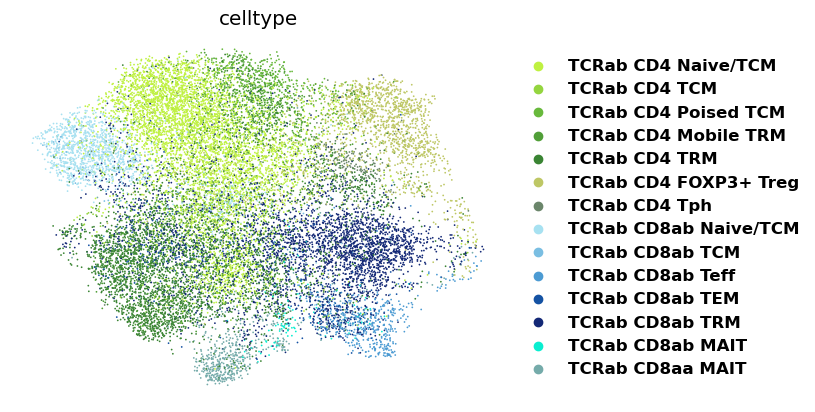

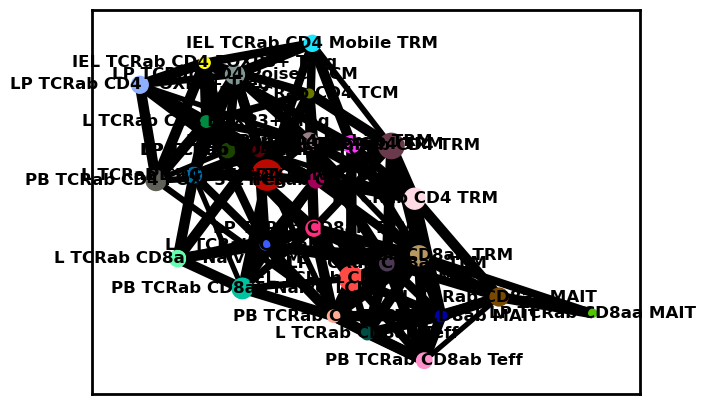

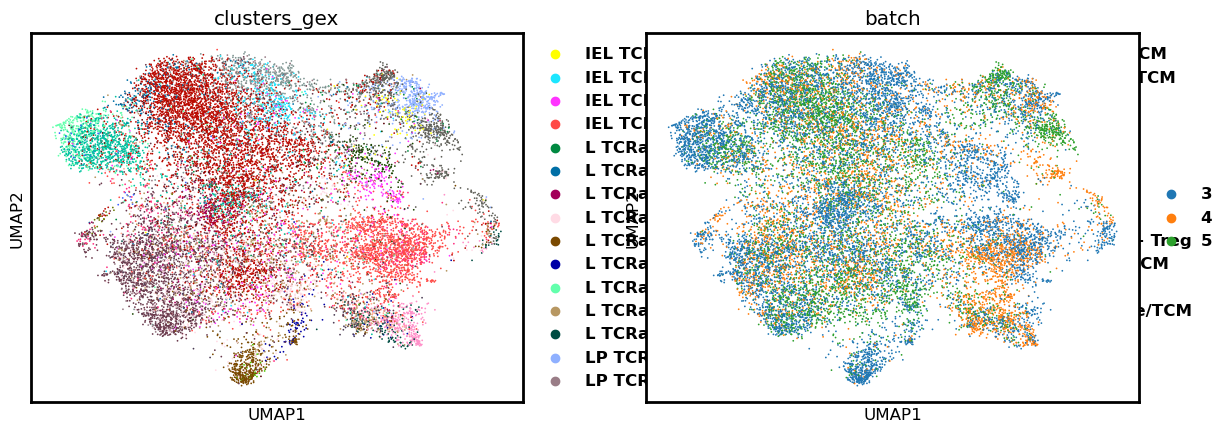

In [ ]:
scvi.model.SCVI.setup_anndata(adata_ab, batch_key='sample_id')
model = scvi.model.SCVI(adata_ab, n_layers=2, n_latent=30)
model.train(max_epochs=200)
model.save("250814_scVI", overwrite=True)
adata_ab.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_ab, use_rep="X_scVI")
sc.tl.umap(adata_ab)

# Visualize datasets integrated by scVI
sc.pl.umap(adata_ab, color='celltype', frameon=False)
sc.tl.paga(adata_ab,groups = 'tissue+celltype')
sc.pl.paga(adata_ab, threshold = 0.5)
sc.tl.umap(adata_ab, min_dist = 0.2, spread = 1)
sc.pl.umap(adata_ab, color = ['clusters_gex','batch'])

In [60]:
X_umap = adata_ab.obsm['X_umap']
X_scVI = adata_ab.obsm['X_scVI']

In [61]:
adata_ab = conga.preprocess.cluster_and_tsne_and_umap( adata_ab )

computing X_pca_gex using sc.tl.pca
running 1D UMAP gex


c:\users\andre\conga\conga\preprocess.py:784: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=cluster_key_added)


ran leiden clustering: leiden_gex
running 1D UMAP tcr
ran leiden clustering: leiden_tcr


In [9]:
# conga.preprocess.calc_tcrdist_nbrs_umap_clusters_cpp(adata_ab,10,make_1d_umaps=True,
#                                                      tmpfile_prefix=r"C:\Users\andre\conga\tcrdist_cpp\tmp_gut_liver",
#                                                      clustering_method='leiden',
#                                                      clustering_resolution=1)
#jump out and run the cmd in wsl command line because of the compling issue with windows
#dos2unix /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_tcrs.tsv
#/mnt/c/Users/andre/conga/tcrdist_cpp/bin/find_neighbors   -f /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_tcrs.tsv   -n 10   -d /mnt/c/Users/andre/conga/tcrdist_cpp/db/tcrdist_info_human.txt   -o /mnt/c/Users/andre/conga/tcrdist_cpp/tmp_gut_liver_calc_tcrdist
#and move file back to wd



# #I just adapted this from conga cuz it process the tcr info separately on their TCRdist
# tag = 'tcr'
# adata_ab.obsm['X_pca'] = adata_ab.obsm['X_pca_' + tag]
# n_pcs = adata_ab.obsm['X_pca'].shape[1]

# # Compute neighbors using TCR PCs
# sc.pp.neighbors(adata_ab, n_neighbors=10, n_pcs=n_pcs)

# # Run UMAP
# sc.tl.umap(adata_ab, min_dist=0.5, spread=1.0)
# adata_ab.obsm['X_umap_' + tag] = adata_ab.obsm['X_umap']

# # Run 1D UMAP (optional)
# sc.tl.umap(adata_ab, n_components=1)
# adata_ab.obsm[f'X_{tag}_1d'] = adata_ab.obsm['X_umap']

# # Run Leiden clustering
# sc.tl.leiden(adata_ab, resolution=1.0, key_added='leiden_' + tag)
# adata_ab.obs['clusters_' + tag] = adata_ab.obs['leiden_' + tag].astype(int)

# adata_ab.obsm['X_{}_2d'.format(tag)] = adata_ab.obsm['X_umap_'+tag]

C:\Users\andre\AppData\Local\Temp\ipykernel_28572\1448302590.py:27: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_ab, resolution=1.0, key_added='leiden_' + tag)


In [104]:
# celltype_color_dict = pd.DataFrame([adata_ab.obs['celltype'].values.categories,adata_ab.uns['celltype_colors']]).T.set_index(0)[1].to_dict()
# adata_ab.obs['celltype_colorcode'] = adata_ab.obs['celltype'].replace(celltype_color_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_23812\1797453036.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_ab.obs['celltype_colorcode'] = adata_ab.obs['celltype'].replace(celltype_color_dict)


In [62]:
adata_ab.obsm['X_pca_gex'] = X_scVI
adata_ab.obsm['X_gex_2d'] = X_umap
adata_ab.obs['clusters_gex'] = adata_ab.obs['tissue+celltype']
# adata_ab.obs.groupby('tissue+celltype').ngroup().astype('str')
adata_ab.obs['clusters_gex'].values.categories.shape

(29,)

C:\Users\andre\AppData\Local\Temp\ipykernel_14544\1108244951.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values


Text(0.5, 1.0, 'TCR UMAP colored by TCR clusters')

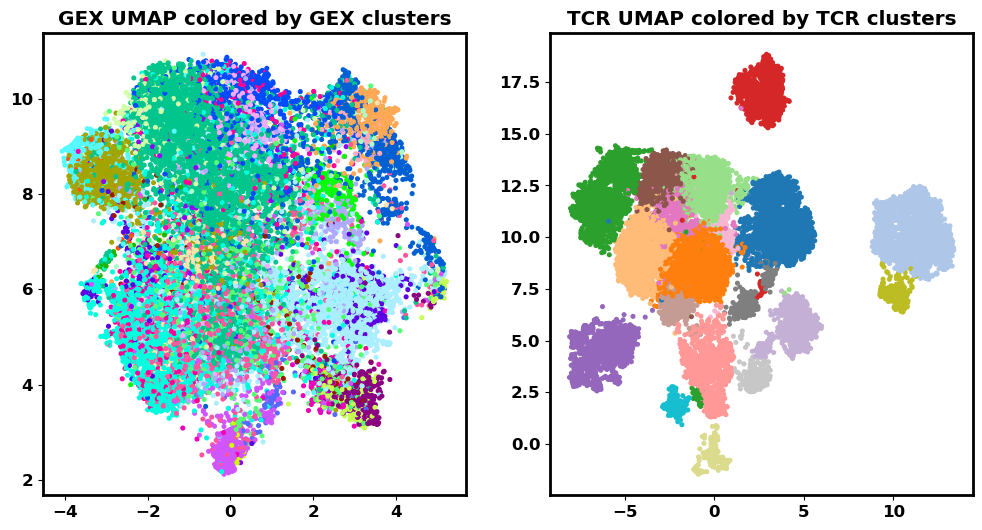

In [63]:
plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata_ab.obsm['X_gex_2d']
clusters_gex_num = adata_ab.obs.groupby(['clusters_gex']).ngroup().astype(int).values
cmap = plt.get_cmap('tab20')
# colors = adata_ab.obs['celltype_colorcode']
colors = [cmap_30.colors[34-x] for x in clusters_gex_num]
GEX_color_array = colors

plt.scatter( xy[:,0], xy[:,1], c=colors,s =7)
# plt.legend()
plt.title('GEX UMAP colored by GEX clusters',fontweight = 'bold')

plt.subplot(122)
xy = adata_ab.obsm['X_tcr_2d']
clusters = np.array(adata_ab.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors,s =7)
plt.title('TCR UMAP colored by TCR clusters',fontweight = 'bold')

In [64]:
color_df = pd.DataFrame(adata_ab.obs['tissue+celltype'])
color_df['clusters_gex_num'] = clusters_gex_num
color_df['tissue_celltype_colors'] = GEX_color_array
color_df['cluster_legend'] = color_df['clusters_gex_num'].astype(str).map(str) + ': ' + color_df['tissue+celltype'].astype(str).map(str)    
color_df = color_df.drop_duplicates(subset = 'cluster_legend')
color_df = color_df.set_index('cluster_legend')
color_dict_30 = color_df['tissue_celltype_colors'].sort_index().to_dict()
color_dict_30

{'0: IEL TCRab CD4 FOXP3+ Treg': array([1.        , 0.66666667, 0.75196084, 1.        ]),
 '10: L TCRab CD8ab Naive/TCM': array([0.33333333, 0.9772078 , 1.        , 1.        ]),
 '11: L TCRab CD8ab TRM': array([0.33333333, 1.        , 0.46691265, 1.        ]),
 '12: L TCRab CD8ab Teff': array([0.77107754, 1.        , 0.33333333, 1.        ]),
 '13: LP TCRab CD4 FOXP3+ Treg': array([1.        , 0.65759836, 0.33333333, 1.        ]),
 '14: LP TCRab CD4 Mobile TRM': array([1.        , 0.        , 0.58014755, 1.        ]),
 '15: LP TCRab CD4 Naive/TCM': array([0.5628663, 0.       , 1.       , 1.       ]),
 '16: LP TCRab CD4 Poised TCM': array([0.        , 0.29411985, 1.        , 1.        ]),
 '17: LP TCRab CD4 TRM': array([0.       , 1.       , 0.8720566, 1.       ]),
 '18: LP TCRab CD4 Tph': array([0.01580815, 1.        , 0.0308837 , 1.        ]),
 '19: LP TCRab CD8aa MAIT': array([0.81874882, 1.        , 0.        , 1.        ]),
 '1: IEL TCRab CD4 Mobile TRM': array([0.97009771, 0.6666

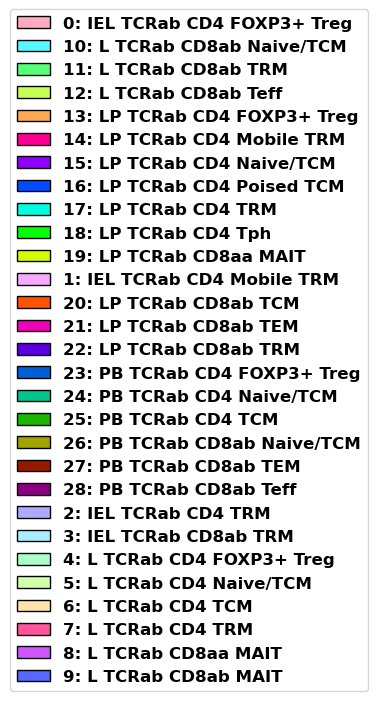

In [65]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=celltype)
    for celltype, color in color_dict_30.items()
]

# Create figure and add legend
plt.figure(figsize=(4, 2))
plt.legend(handles=legend_elements, loc='center', frameon=True)
plt.axis('off')  # Hide axes
# plt.title("Cell Type Color Legend")
plt.show()

In [66]:
joblib.dump(color_dict_30, 'color_dict_30.pkl')
# color_dict_30 = joblib.load('color_dict_30.pkl')

['color_dict_30.pkl']

Text(0.5, 1.0, 'GEX UMAP colored by TCR clusters')

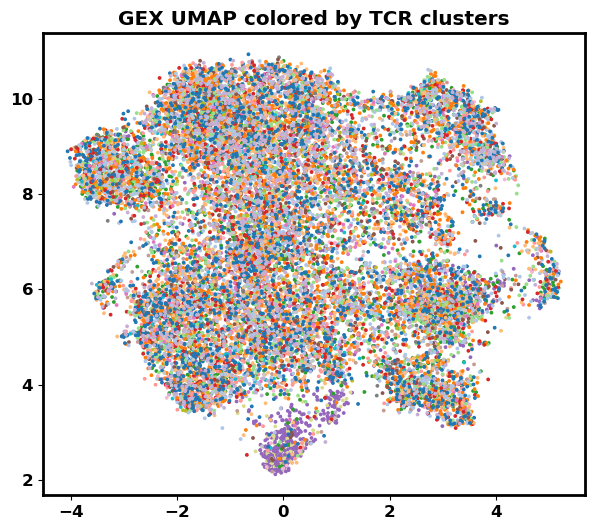

In [67]:
plt.figure(figsize=(7,6))
xy = adata_ab.obsm['X_gex_2d']
clusters = np.array(adata_ab.obs['clusters_tcr'])
cmap = plt.get_cmap('tab20')
colors = [ cmap.colors[x%20] for x in clusters]
plt.scatter( xy[:,0], xy[:,1], c=colors,s=3)
plt.title('GEX UMAP colored by TCR clusters',fontweight = 'bold')

In [68]:
adata_ab.write('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')
# adata_ab = sc.read_h5ad('250721_gut_liver_TRM_adata_abTCR_conga.h5ad')

In [69]:
# these are the nbrhood sizes, as a fraction of the entire dataset:
nbr_fracs = [0.01, 0.1]

# we use this nbrhood size for computing the nndists
nbr_frac_for_nndists = 0.01

all_nbrs, nndists_gex, nndists_tcr = conga.preprocess.calc_nbrs(
    adata_ab, nbr_fracs, also_calc_nndists=True, nbr_frac_for_nndists=nbr_frac_for_nndists)

# stash these in obs array, they are used in a few places...
adata_ab.obs['nndists_gex'] = nndists_gex
adata_ab.obs['nndists_tcr'] = nndists_tcr
# adata_ab.uns['all_nbrs'] = all_nbrs
conga.preprocess.setup_tcr_cluster_names(adata_ab) #stores in adata_ab.uns

retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present
allocating memory for 3535716 gex nbrs
allocated 14142864 bytes memory id= 3109533331696
allocating memory for 3535716 tcr nbrs
allocated 14142864 bytes memory id= 3109533334480
allocating memory for 35357160 gex nbrs
allocated 141428640 bytes memory id= 3109533468208
allocating memory for 35357160 tcr nbrs
allocated 141428640 bytes memory id= 3109533468880
compute D gex batch= 0 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: gex batch= 0 nbr_frac= 0.01
argpartitions: gex batch= 0 nbr_frac= 0.1
compute D tcr batch= 0 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: tcr batch= 0 nbr_frac= 0.01
argpartitions: tcr batch= 0 nbr_frac= 0.1
compute D gex batch= 1 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: gex batch= 1 nbr_frac= 0.01
argpartitions: gex batch= 1 nbr_frac= 0.1
compute D tcr batch= 1 num_batches= 6 N= 18807 batch_size= 3568
argpartitions: tcr batch= 1 nbr_frac= 0.01

In [70]:
joblib.dump(all_nbrs, '0813_all_nbrs.pkl')
# all_nbrs = joblib.load('all_nbrs.pkl')

['0813_all_nbrs.pkl']

In [71]:
adata_ab.write('C:/Users/andre/250813_gut_liver_TRM_adata_abTCR_conga.h5ad')
# adata_ab = sc.read_h5ad('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')

### now conga is comparing the TCR graph and GEX graph

In [15]:
results = conga.correlations.run_graph_vs_graph(
    adata_ab, all_nbrs, outfile_prefix='C:/Users/andre/0813_'+outfile_prefix)
results.head()

retrieve_tcrs_from_adata: include_subject_id_if_present is True and subject_id present
find_neighbor_neighbor_interactions:
find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


find_neighbor_neighbor_interactions:


...

find_neighbor_cluster_interactions:


c:\users\andre\conga\conga\correlations.py:189: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction=np.sum(is_mait[same_cluster_nbrs])/overlap


saved graph_vs_graph results to tsvfile: C:/Users/andre/0813_conga_output_gut_liver_TRM_graph_vs_graph.tsv


c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\andre\conga\conga\correlations.py:646: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_df[tag] = list(adata.obs[tag][indices])
c:\users\a

,conga_score,num_neighbors_gex,num_neighbors_tcr,overlap,overlap_corrected,mait_fraction,clone_index,nbr_frac,graph_overlap_type,cluster_size,gex_cluster,tcr_cluster,va,ja,cdr3a,vb,jb,cdr3b
2989,1.000000e-100,NaN,1880.0,420,187,0.938095,319,0.1,gex_cluster_vs_tcr_nbr,577.0,L TCRab CD8aa MAIT,8,TRAV1-2*01,TRAJ12*01,CAVLDSSYKLIF,TRBV6-4*01,TRBJ2-2*01,CASSAGQGETGELFF
3039,1.000000e-100,NaN,1880.0,419,190,0.926014,412,0.1,gex_cluster_vs_tcr_nbr,575.0,L TCRab CD8aa MAIT,8,TRAV1-2*01,TRAJ20*01,CAVRDDDYKLSF,TRBV6-4*01,TRBJ2-3*01,CASSVAGEADTQYF
2982,1.000000e-100,NaN,1880.0,419,186,0.942721,309,0.1,gex_cluster_vs_tcr_nbr,577.0,L TCRab CD8aa MAIT,8,TRAV1-2*01,TRAJ12*01,CAVEDSSYKLIF,TRBV6-4*01,TRBJ2-1*01,CASSDLAGEGNEQFF
2986,1.000000e-100,NaN,1880.0,428,205,0.892523,314,0.1,gex_cluster_vs_tcr_nbr,576.0,L TCRab CD8aa MAIT,17,TRAV1-2*01,TRAJ12*01,CAVKDSSYKLIF,TRBV20-1*01,TRBJ2-3*01,CSARDLSGGESDTQYF
2981,1.000000e-100,NaN,1880.0,418,186,0.942584,307,0.1,gex_cluster_vs_tcr_nbr,577.0,L TCRab CD8aa MAIT,8,TRAV1-2*01,TRAJ12*01,CATMDSSYKLIF,TRBV6-4*01,TRBJ2-1*01,CASSEGPEREQFF


C:\Users\andre\AppData\Local\Temp\ipykernel_29196\1098599648.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
C:\Users\andre\AppData\Local\Temp\ipykernel_29196\1098599648.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))


(np.float64(-9.183576679229736),
 np.float64(14.454902744293213),
 np.float64(-2.4888642549514772),
 np.float64(19.865225625038146))

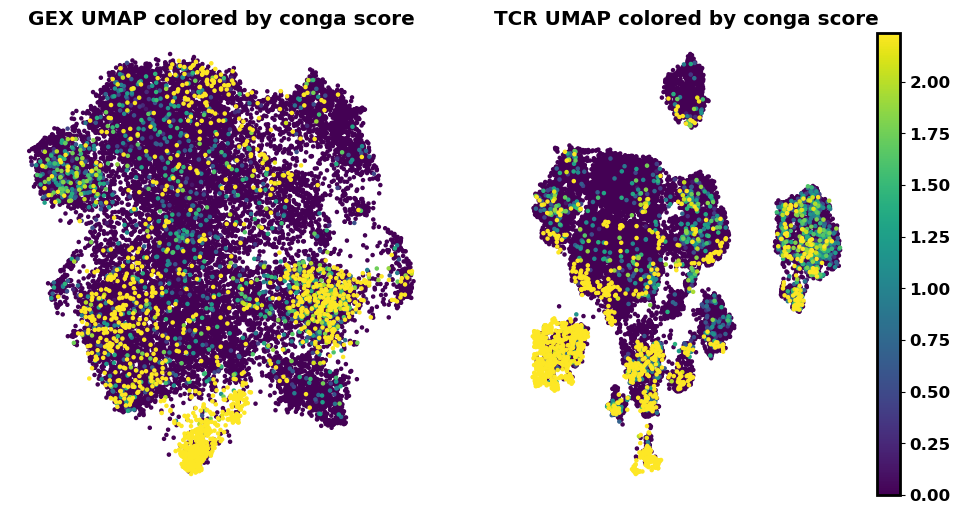

In [16]:
#put the conga hits on top
conga_scores = adata_ab.obs['conga_scores']
colors = np.sqrt(np.maximum(-1*np.log10(conga_scores),0.0))
reorder = np.argsort(colors)

plt.figure(figsize=(12,6))
plt.subplot(121)
xy = adata_ab.obsm['X_gex_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
plt.title('GEX UMAP colored by conga score',fontweight = 'bold')
plt.axis('off')

plt.subplot(122)
xy = adata_ab.obsm['X_tcr_2d']
plt.scatter( xy[reorder,0], xy[reorder,1], c=colors[reorder], s=5, vmin=0, vmax=np.sqrt(5))
plt.colorbar()
plt.title('TCR UMAP colored by conga score',fontweight = 'bold')
plt.axis('off')

In [21]:
adata_ab.obs['clusters_gex'] = clusters_gex_num

In [22]:
adata_ab.obs['clusters_gex']

ATCCACCAGCGCCTCA-1-3-LP     17
CCATGTCTCGCCAAAT-1-3-IEL     3
ATCTACTCACTTCGAA-1-3-LP     17
GATGAAACACTTCGAA-1-3-LP     16
TTCTCAAAGTCTTGCA-1-4-IEL     3
                            ..
GGCTGGTTCCTTGCCA-1-3-LP     16
CAGGTGCAGTTGAGAT-1-3-PB     24
GACCTGGTCACAGTAC-1-3-IEL     1
TACCTATGTTCCGTCT-1-3-IEL     2
GGGACCTAGCTAGTGG-1-5-IEL     3
Name: clusters_gex, Length: 18807, dtype: int64

In [ ]:
adata_ab.obs['gex_colors'] = GEX_color_array
GEX_color_dict = adata_ab.obs[['clusters_gex','gex_colors']].set_index('clusters_gex')['gex_colors'].sort_index().to_dict()
GEX_color_dict

{0: array([1.        , 0.66666667, 0.75196084, 1.        ]),
 1: array([0.97009771, 0.66666667, 1.        , 1.        ]),
 2: array([0.68443566, 0.66666667, 1.        , 1.        ]),
 3: array([0.66666667, 0.93455973, 1.        , 1.        ]),
 4: array([0.66666667, 1.        , 0.78750016, 1.        ]),
 5: array([0.8314946 , 1.        , 0.66666667, 1.        ]),
 6: array([1.        , 0.89056395, 0.66666667, 1.        ]),
 7: array([1.        , 0.33333333, 0.61201002, 1.        ]),
 8: array([0.81666588, 0.33333333, 1.        , 1.        ]),
 9: array([0.33333333, 0.4058837 , 1.        , 1.        ]),
 10: array([0.33333333, 0.9772078 , 1.        , 1.        ]),
 11: array([0.33333333, 1.        , 0.46691265, 1.        ]),
 12: array([0.77107754, 1.        , 0.33333333, 1.        ]),
 13: array([1.        , 0.65759836, 0.33333333, 1.        ]),
 14: array([1.        , 0.        , 0.58014755, 1.        ]),
 15: array([0.5628663, 0.       , 1.       , 1.       ]),
 16: array([0.        

In [77]:
joblib.dump(GEX_color_dict,'0813_GEX_color_dict.pkl')

['0813_GEX_color_dict.pkl']

In [ ]:
# del adata_ab.obs['gex_colors']
adata_ab.write('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')
adata_ab = sc.read_h5ad('250813_gut_liver_TRM_adata_abTCR_conga.h5ad')

making tcr score table, #features= 35
WARNING nndists_tcr score requested but not present in adata.obs!!!!


c:\users\andre\conga\conga\correlations.py:977: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mait_fraction = np.sum(nbrhood_is_mait[ top_indices ] )\


run rank_genes_groups [('none', 16599), ('clp_8_8', 296), ('clp_3_8', 224), ('clp_26_1', 153), ('clp_14_7', 144), ('clp_3_1', 136), ('clp_17_0', 128), ('clp_8_17', 112), ('clp_24_7', 95), ('clp_24_1', 84), ('clp_24_16', 62), ('clp_14_3', 55), ('clp_26_4', 54), ('clp_3_2', 53), ('clp_3_4', 47), ('clp_9_8', 43), ('clp_24_9', 42), ('clp_3_5', 35), ('clp_24_18', 35), ('clp_14_2', 34), ('clp_14_15', 34), ('clp_14_0', 33), ('clp_11_8', 30), ('clp_23_1', 30), ('clp_7_8', 28), ('clp_14_9', 27), ('clp_14_18', 24), ('clp_14_16', 23), ('clp_14_1', 21), ('clp_3_0', 21), ('clp_17_14', 20), ('clp_3_3', 20), ('clp_14_4', 17), ('clp_3_6', 17), ('clp_14_11', 16), ('clp_19_8', 15)]


c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanp

WARNING nndists_tcr score requested but not present in adata.obs!!!!
low_std: nndists_tcr 0.0
making cluster logos: 0 35 conga_output_gut_liver_TRM_graph_vs_graph_logos.png


...

conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_8_8_1.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_8_8_1.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_8_8_2.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_8_8_2.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_8_A.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_8_A.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_8_B.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_8_8_B.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_8_8.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_8_8.png"
making cluster logos: 33 35 conga_output

c:\users\andre\conga\conga\plotting.py:1186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_cells = sum( clone_sizes[x] for x in nodes )


conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_11_8_1.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_11_8_1.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_11_8_2.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_11_8_2.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_11_8_A.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_11_8_A.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_11_8_B.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_11_8_B.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_11_8.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_11_8.png"
making cluster logos: 34 35 co

c:\users\andre\conga\conga\plotting.py:1186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_cells = sum( clone_sizes[x] for x in nodes )


conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_9_8_1.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_9_8_1.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_9_8_2.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmp_9_8_2.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_A.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_A.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_B.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png_tmp_9_8_B.png"
conga.convert_svg_to_png: convert failed, command="convert conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_9_8.svg conga_output_gut_liver_TRM_graph_vs_graph_logos.png.tmpsc_9_8.png"
making: conga_output_gut_liver_TRM_graph

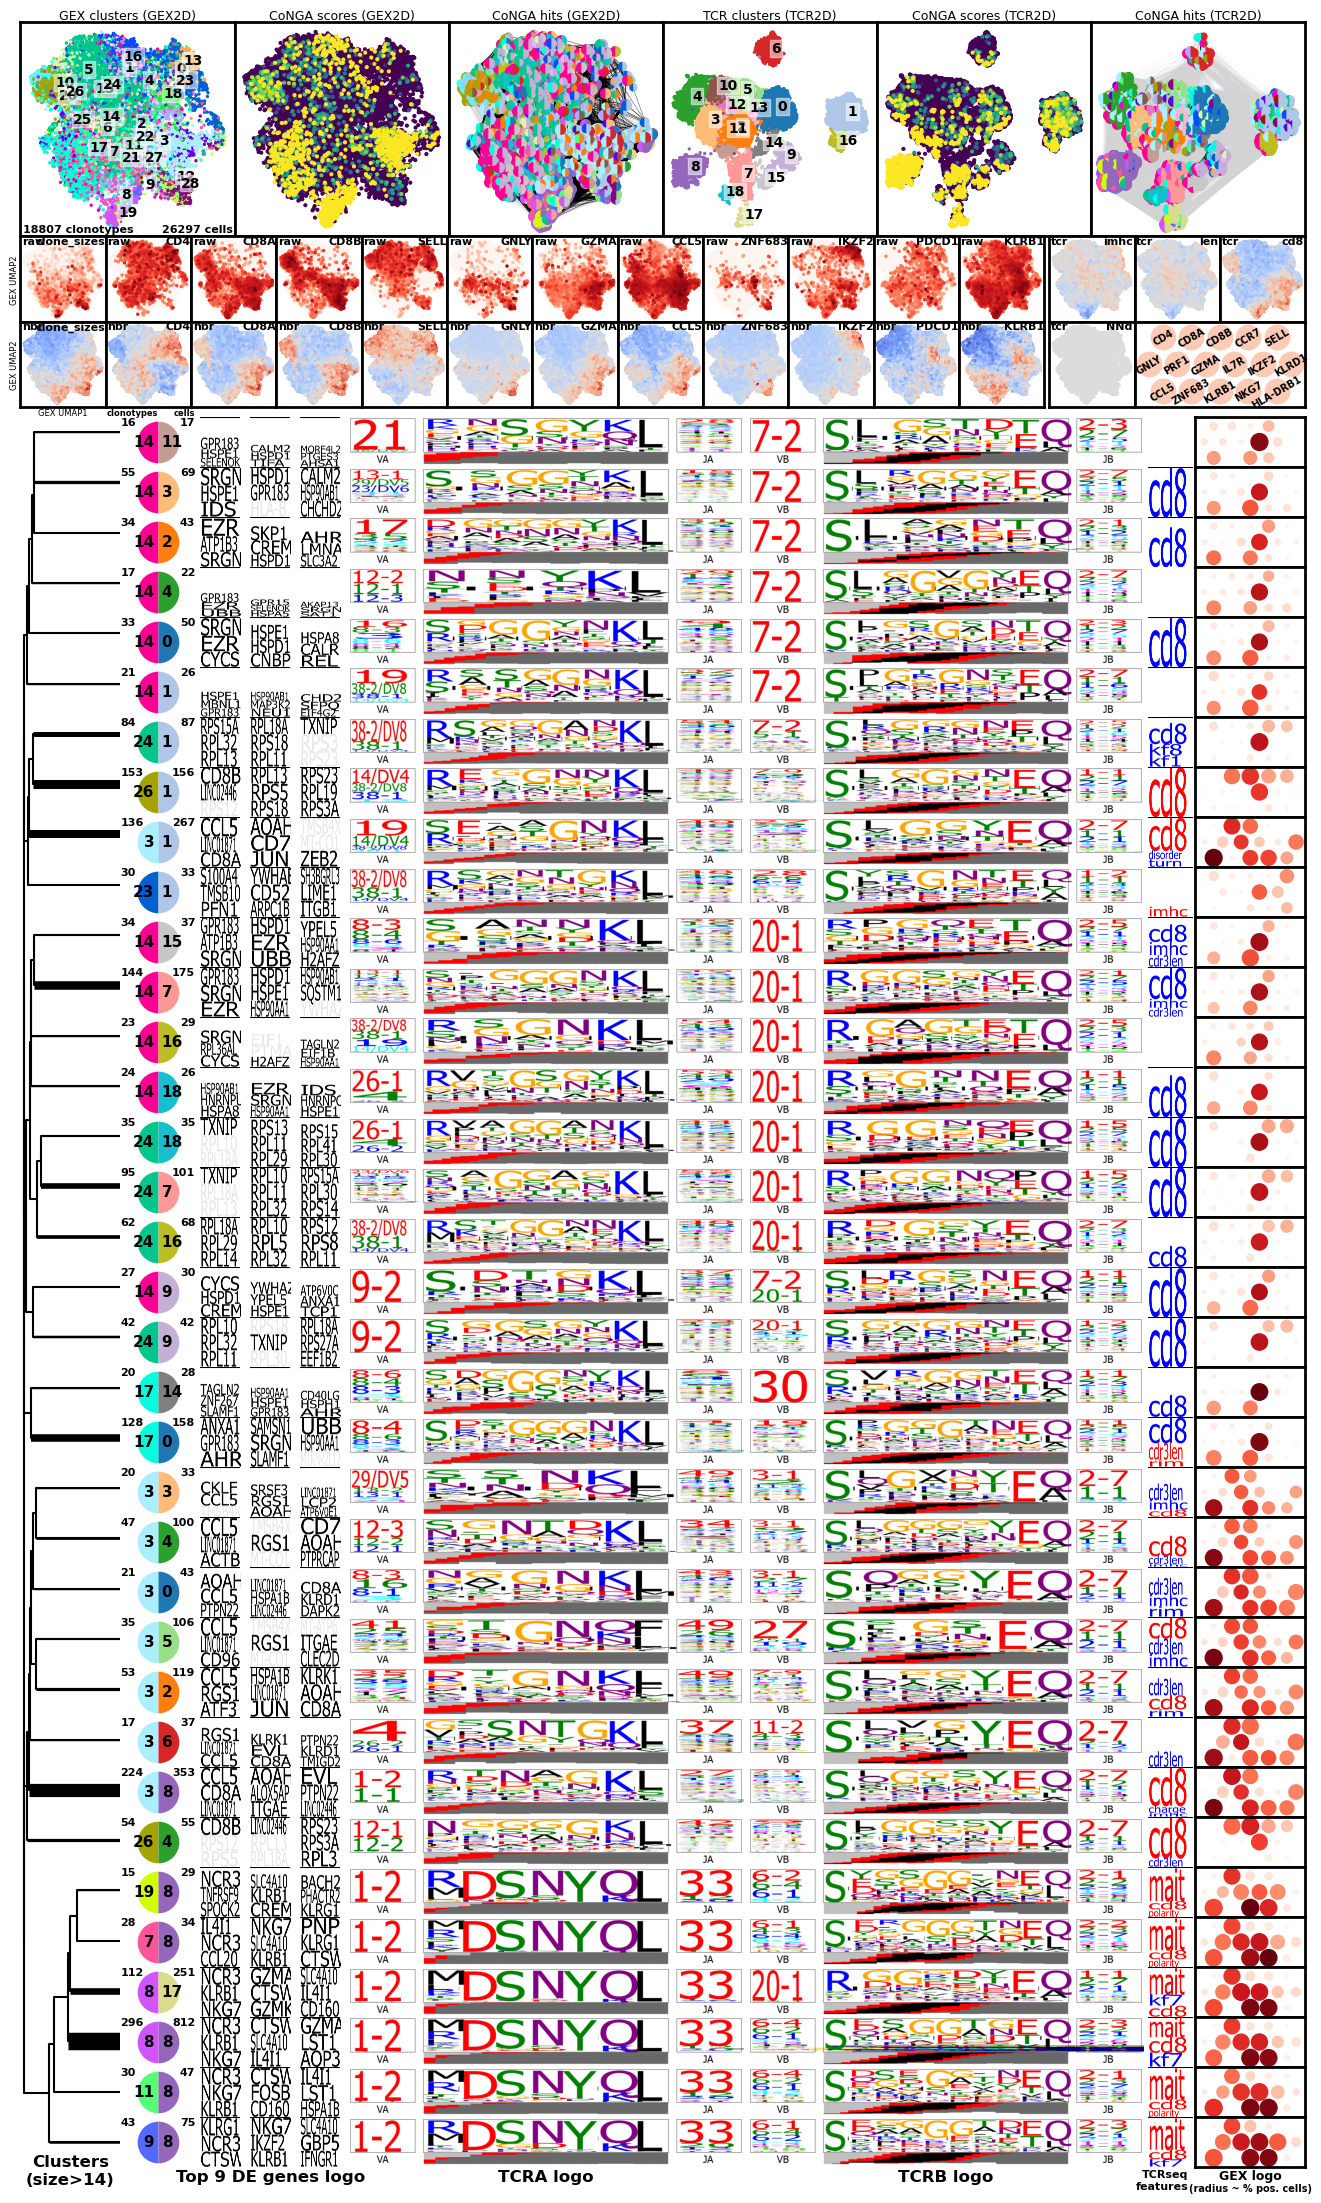

In [23]:
os.chdir(r'C:\Users\andre\revision\result')
nbrs_gex, nbrs_tcr = all_nbrs[0.1]

min_cluster_size = 15
conga.plotting.make_graph_vs_graph_logos(
    adata_ab,
    outfile_prefix,
    min_cluster_size,
    nbrs_gex,
    nbrs_tcr,
    custom_GEX_colormap = GEX_color_array,
    custom_GEX_colormap_dict = GEX_color_dict
)

In [24]:
adata_ab

AnnData object with n_obs × n_vars = 18807 × 1215
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'va', 'ja', 'vb', 'jb', 'clone_code', 'subject_id', 'clone_id', 'cdr3a_nucseq', 'cdr3b_nucseq', 'clusters_gex', 'percent_mito', 'sample_id', '_scvi_batch', '_scvi_labels', 'clone_sizes', 'gex_variation', 'leiden_gex', 'leiden_tcr', 'clusters_tcr', 'gex_colors', 'is_invariant', 'conga_sc

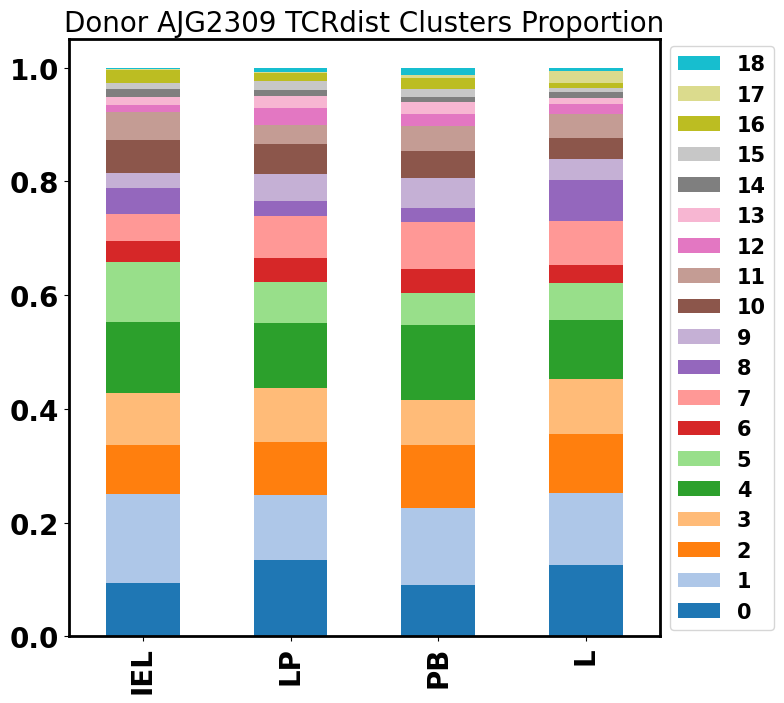

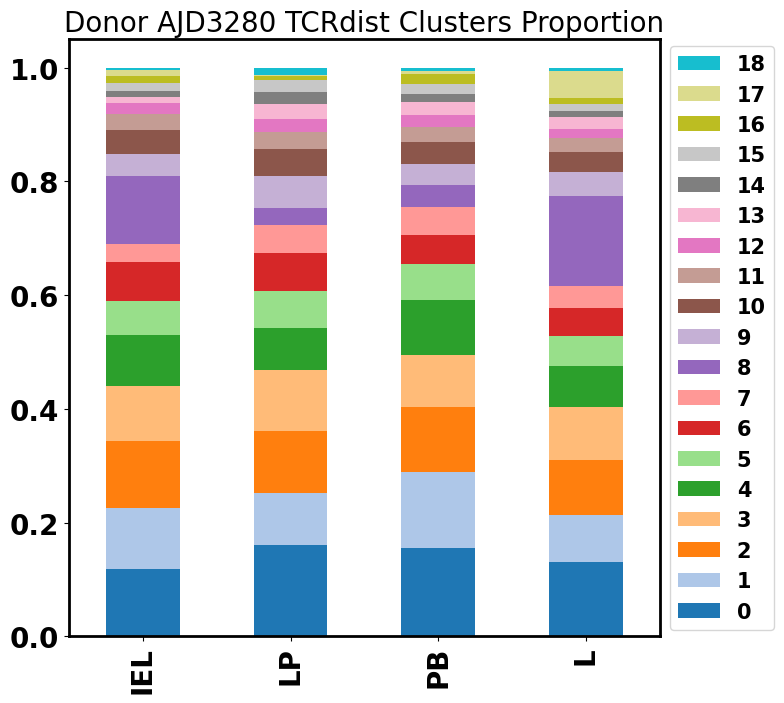

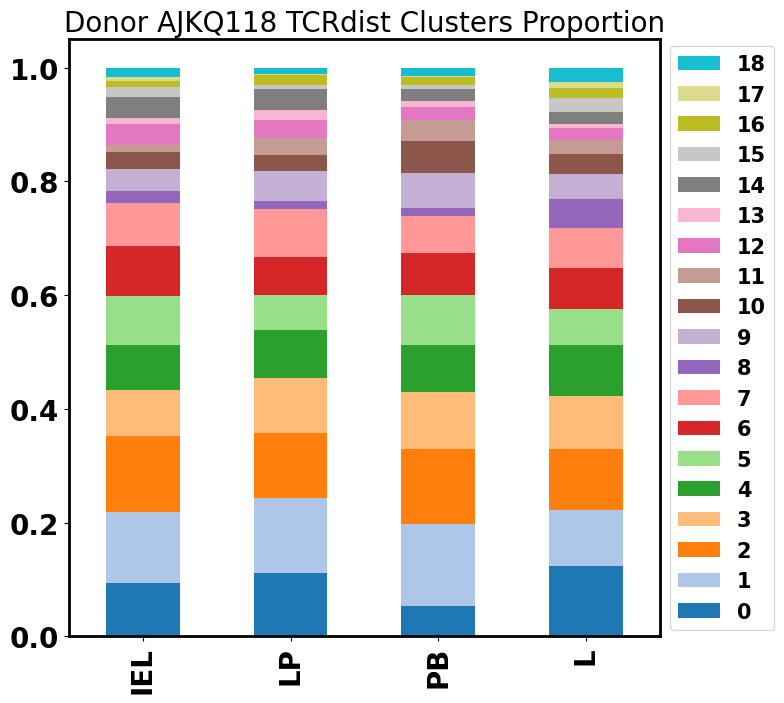

In [25]:
plt.rcParams['figure.figsize'] = [8,7.2]
cat_order = adata_ab.obs['clusters_tcr'].astype("category").values.categories
MAIT_frac = dict()
gammadelta_frac = dict()
cmap = plt.get_cmap('tab20')
clusters = np.array(adata_ab.obs['clusters_tcr'])
tcr_cluster_colors =  cmap.colors
for j in set(adata_ab.obs['Donor ID']):
    expand_subtype = pd.DataFrame()
    adata_temp = adata_ab[adata_ab.obs['Donor ID'] == j,:]
    for i in set(adata_ab.obs['tissue']):
        pdtemp = pd.DataFrame(adata_temp[adata_temp.obs['tissue'] == i,:].obs['clusters_tcr'].value_counts(normalize = True))
        pdtemp = pdtemp.rename({'proportion': i }, axis='columns')
        expand_subtype = pd.concat([expand_subtype, pdtemp], ignore_index=False, axis=1)
    expand_subtype = expand_subtype.reindex(index =cat_order)
    expand_subtype.transpose().plot.bar(stacked=True,color = tcr_cluster_colors,fontsize = 20 ).legend(loc='center left',bbox_to_anchor=(1.0, 0.5),fontsize = 15,reverse=True)
    plt.title(label = j +' TCRdist Clusters Proportion', fontsize = 20)
    plt.tight_layout()
    # plt.savefig(j+' Major celltype breakdown in tissues.png',dpi = 300)

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\377005691.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_ab.obs.groupby('tissue+celltype')['conga_score_reverted'].mean().sort_values().plot.bar()


<Axes: xlabel='tissue+celltype'>

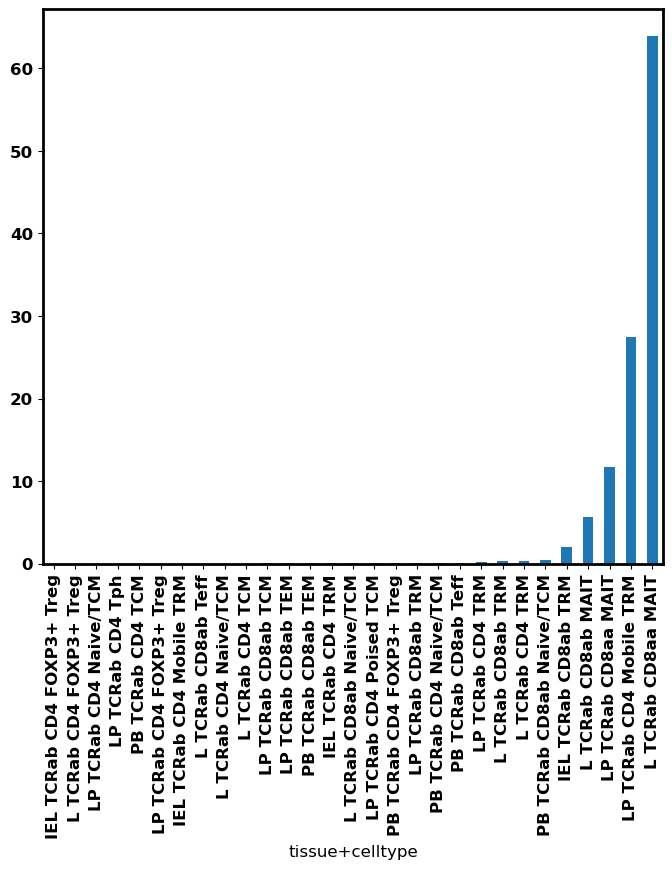

In [26]:
# Note that Conga essentially reduce to 1 cell 1 clonotype
# so the celltype of the cell who got assigned to that clone is not necessarily representative of all celltypes in that clone
conga_score_reverted = np.array([max(0, -1*np.log10(x)) for x in adata_ab.obs['conga_scores']]) #significance at 1/18806
adata_ab.obs['conga_score_reverted'] = conga_score_reverted
adata_ab.obs.groupby('tissue+celltype')['conga_score_reverted'].mean().sort_values().plot.bar()
# plt.yscale('log')

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_conga_hits(adata, all_nbrs, gex_colors,tcr_colors,markersize_coeff = 2, #min_cluster_size = 15,
    draw_edges_between_conga_hits = True,
    ignore_tcr_cluster_colors = False,
    show_real_clusters_gex = False,
    pretty = True, conga_scores_name= 'CoNGA', proj_tag = 'GEX TCR'
):
    nbrs_gex, nbrs_tcr = all_nbrs[0.1]

    adata.obsm['nbrs_gex'] = nbrs_gex
    adata.obsm['nbrs_tcr'] = nbrs_tcr
    
    # adata = adata[adata.obs['clone_sizes']>= min_cluster_size]
    
    clusters_gex = adata.obs['clusters_gex']
    clusters_tcr = adata.obs['clusters_tcr']
    conga_scores = adata.obs['conga_scores']
    good_score_mask = np.array(conga_scores) <= 1.0
    X_gex_2d = adata.obsm['X_gex_2d']
    # X_tcr_2d = adata.obsm['X_tcr_2d']
    
    # nbrs_gex = adata.obsm['nbrs_gex']
    # nbrs_tcr = adata.obsm['nbrs_tcr'] 

    node2cluspair = {
        i:(x,y) for i,(x,y,m) in enumerate(zip(clusters_gex,
                                                clusters_tcr,
                                                good_score_mask)) if m} #all cells, the index of cell: (its gex cluster, its tcr cluster) if conga score is high enough
    cluspair2nodes = {}
    for node, clp in node2cluspair.items(): #clp probably stands for cluster pairs
        cluspair2nodes.setdefault(clp,[]).append(node)

    all_dbl_nbrs = {}
    for ii in node2cluspair:
        gex_nbrs = frozenset( nbrs_gex[ii]) #get cell ii's gex neighbors
        all_dbl_nbrs[ii] = [ x for x in nbrs_tcr[ii]
                                if good_score_mask[x] and x in gex_nbrs ] #both the gex and tcr neighbors for cell ii, I think

    all_xy_gex = { i:xy for i,xy in enumerate(X_gex_2d) }

    icol = 0
    # Draw edges
    intra_lines = []
    inter_lines = []
    seen_line = set()
    for ii in node2cluspair:
        for jj in all_dbl_nbrs[ii]: #jj is one of the ii cell's double-sided neighbors
            if (jj, ii) not in seen_line:
                seen_line.add((ii, jj))
                line = [[all_xy_gex[ii][0], all_xy_gex[ii][1]], [all_xy_gex[jj][0], all_xy_gex[jj][1]]]
                if node2cluspair[ii] == node2cluspair[jj]: #if jj and ii are in the same tcr cluster and gex cluster, draw a dark line between them
                    intra_lines.append(line)
                else:
                    inter_lines.append(line)

    if draw_edges_between_conga_hits:
        light_gray = "#8D8D8D"
        line_segments = LineCollection(inter_lines, linewidths=0.25, zorder=1, colors=light_gray, alpha=0.05)
        plt.gca().add_collection(line_segments)

        # dark_gray = '#888888'
        # line_segments = LineCollection(intra_lines, linewidths=0.25, zorder=1, colors='k')
        # plt.gca().add_collection(line_segments)

    # Plot nodes
    for clp, nodes in cluspair2nodes.items():
        xvals = np.array([all_xy_gex[x][0] for x in nodes])
        yvals = np.array([all_xy_gex[x][1] for x in nodes])
        cscores = np.array([conga_scores[x] for x in nodes])

        if ignore_tcr_cluster_colors:
            plt.plot(xvals, yvals,
                     zorder=2,
                     marker='o',
                     linestyle='None',
                     color=gex_colors[clp[0]],
                     markeredgecolor='none',
                     markeredgewidth=0)
        else:
            for score_threshold, markersize in [[1., 6], [1e-1, 7], [1e-2, 8]]:
                mask = cscores <= score_threshold
                if np.sum(mask) == 0:
                    continue
                reorder = np.argsort(cscores[mask])[::-1]
                left_color = 'none' if show_real_clusters_gex else gex_colors[clp[0]]
                plt.plot(xvals[mask][reorder], yvals[mask][reorder],
                         zorder=2,
                         marker='o',
                         linestyle='None',
                         markersize=markersize*markersize_coeff,
                         color=left_color,
                         markerfacecoloralt=tcr_colors[clp[1]],
                         fillstyle='left',
                         markeredgecolor='none',
                         markeredgewidth=0)

    # Formatting
    plt.xticks([], [])
    plt.yticks([], [])
    # plt.xlim((xmin, xmax))
    # plt.ylim((ymin, ymax))

    if pretty:
        plt.title(f'{conga_scores_name} hits', fontsize=20, fontweight = 'bold', pad=1)
        plt.xlabel(f'{proj_tag} UMAP1', fontweight = 'bold', fontsize=15) #, labelpad=1
    else:
        plt.title(f'{conga_scores_name} hits ({proj_tag}2D)',fontweight = 'bold',  fontsize=20, pad=1)

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\849530451.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cscores = np.array([conga_scores[x] for x in nodes])


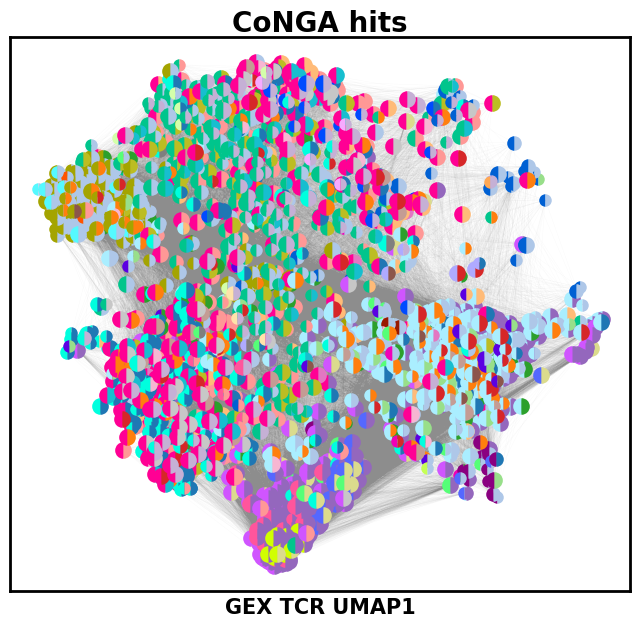

In [28]:
plot_conga_hits(adata_ab,all_nbrs, GEX_color_dict, cmap.colors,markersize_coeff = 1.5)#,min_cluster_size=15)

In [29]:
def rgb_dict_to_hex(d):
    def rgb_to_hex(arr):
        # Accepts array-like of 4 floats (r,g,b,a), ignores alpha
        r, g, b = arr[:3]
        return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))
    return {k: rgb_to_hex(v) for k, v in d.items()}

# Example usage:
color_dict_hex = rgb_dict_to_hex(GEX_color_dict)
color_dict_hex

{0: '#ffaabf',
 1: '#f7aaff',
 2: '#aeaaff',
 3: '#aaeeff',
 4: '#aaffc8',
 5: '#d4ffaa',
 6: '#ffe3aa',
 7: '#ff559c',
 8: '#d055ff',
 9: '#5567ff',
 10: '#55f9ff',
 11: '#55ff77',
 12: '#c4ff55',
 13: '#ffa755',
 14: '#ff0093',
 15: '#8f00ff',
 16: '#004bff',
 17: '#00ffde',
 18: '#04ff07',
 19: '#d0ff00',
 20: '#ff5200',
 21: '#f000b8',
 22: '#5a00e1',
 23: '#0060d3',
 24: '#00c48b',
 25: '#1ab600',
 26: '#a4a300',
 27: '#991800',
 28: '#8a0080'}

In [30]:
adata_ab_copy = adata_ab.copy()
adata_ab_copy.obsm['X_umap'] = adata_ab_copy.obsm['X_umap_gex']
adata_ab_copy.obs['clusters_gex'] = adata_ab_copy.obs['clusters_gex'].astype("category").cat.reorder_categories(GEX_color_dict.keys())
adata_ab_copy = adata_ab_copy[adata_ab_copy.obs['conga_scores'] <= 0.1, :]

c:\Users\andre\AppData\Local\r-miniconda\envs\conga_new_env\lib\site-packages\scanpy\plotting\_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


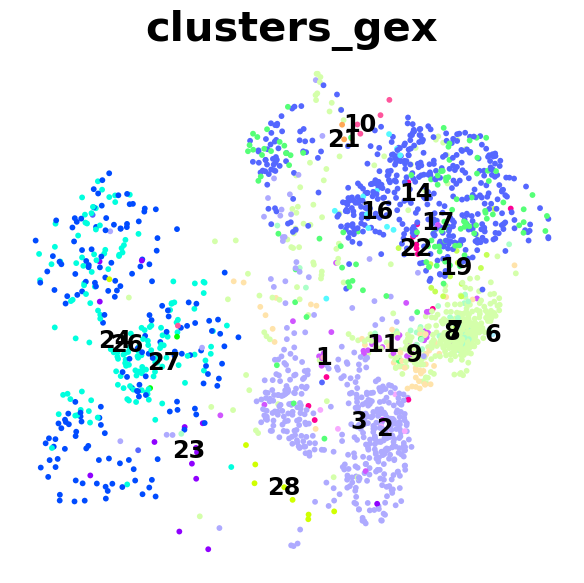

In [31]:
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['figure.figsize'] = [6,6]

plt.close()
fig = sc.pl.umap(adata_ab_copy, color = ['clusters_gex'],legend_loc = 'on data',frameon = False,
                 size = 70, ncols = 1,palette = list(color_dict_hex.values()),
                 return_fig = True, legend_fontsize = 'x-large')
ax = fig.get_axes()
for i in range(0,len(ax)):
    ax[i].xaxis.label.set_fontsize(22)
    ax[i].xaxis.label.set_fontweight('bold')
    ax[i].yaxis.label.set_fontsize(22)
    ax[i].title.set_fontsize(30)
    ax[i].yaxis.label.set_fontweight('bold')
    ax[i].title.set_fontweight('bold')

plt.tight_layout()
# plt.savefig('donor.png',dpi = 300,bbox_inches='tight')

### prepare chord plot

In [32]:
TCR_cluster_df = adata_ab.obs[['Donor ID','tissue+celltype','clone_id','clone_code','clusters_tcr']]
TCR_cluster_df.to_csv('TCRdist_clusters.tsv', sep='\t')

In [35]:
test_df = TCR_cluster_df[['clone_id','clone_code']]
test_df.set_index('clone_code',inplace = True)
clone_id_map_dict = test_df['clone_id'].to_dict()

In [36]:
test_df = TCR_cluster_df[['clone_id','clusters_tcr']]
test_df.set_index('clone_id',inplace = True)
clone_cluster_map_dict = test_df['clusters_tcr'].to_dict()

In [33]:
adata = sc.read_h5ad(r"D:\Trapecar\250307_gut_liver_blood_ultimate_annotated.h5ad")
adata.obs['va'] = adata.obs['TRAV']
adata.obs['ja'] = adata.obs['TRAJ'] 
adata.obs['vb'] = adata.obs['TRBV'] 
adata.obs['jb'] = adata.obs['TRBJ'] 
adata_TCR = adata[adata.obs['chain_pairing'].isin(["single pair", "extra VJ","extra VDJ","two full chains"]),:]
adata_ab_all = adata_TCR[adata_TCR.obs['general type'].isin(['TCRab CD4','TCRab CD8aa','TCRab CD8ab']),:]
adata_ab_all.obs['clone_code'] = adata_ab_all.obs['TRAV'].astype(str).map(str)+' '+adata_ab_all.obs['TRBV'].astype(str).map(str)+' '+adata_ab_all.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab_all.obs['cdr3b'].astype(str).map(str)

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\3493913763.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ab_all.obs['clone_code'] = adata_ab_all.obs['TRAV'].astype(str).map(str)+' '+adata_ab_all.obs['TRBV'].astype(str).map(str)+' '+adata_ab_all.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab_all.obs['cdr3b'].astype(str).map(str)


In [ ]:
adata_ab_all.obs['clone_id'] = adata_ab_all.obs['clone_code']
adata_ab_all.obs['clone_id'] = adata_ab_all.obs['clone_id'].replace(clone_id_map_dict)

In [41]:
adata_ab_all.obs['clusters_tcr'] = adata_ab_all.obs['clone_id']
adata_ab_all.obs['clusters_tcr'] = adata_ab_all.obs['clusters_tcr'].replace(clone_cluster_map_dict)

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\2709424826.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata_ab_all.obs['clusters_tcr'] = adata_ab_all.obs['clusters_tcr'].replace(clone_cluster_map_dict)


In [61]:
TCRdist_df = adata_ab_all.obs[['Donor ID','clone_id','tissue+celltype','clusters_tcr']]
unique_clone_counts = TCRdist_df.groupby(['tissue+celltype', 'clusters_tcr'])['clone_id'].nunique() # I am counting the unique clone belongs to each tissue, each tcr cluster
unique_clone_counts_pivot = unique_clone_counts.unstack(fill_value=0).T
unique_clone_counts_pivot

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\1781025083.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_clone_counts = TCRdist_df.groupby(['tissue+celltype', 'clusters_tcr'])['clone_id'].nunique() # I am counting the unique clone belongs to each tissue, each tcr cluster


tissue+celltype,IEL TCRab CD4 FOXP3+ Treg,IEL TCRab CD4 Mobile TRM,IEL TCRab CD4 TRM,IEL TCRab CD8ab TRM,L TCRab CD4 FOXP3+ Treg,L TCRab CD4 Naive/TCM,L TCRab CD4 TCM,L TCRab CD4 TRM,L TCRab CD8aa MAIT,L TCRab CD8ab MAIT,...,LP TCRab CD8aa MAIT,LP TCRab CD8ab TCM,LP TCRab CD8ab TEM,LP TCRab CD8ab TRM,PB TCRab CD4 FOXP3+ Treg,PB TCRab CD4 Naive/TCM,PB TCRab CD4 TCM,PB TCRab CD8ab Naive/TCM,PB TCRab CD8ab TEM,PB TCRab CD8ab Teff
clusters_tcr,,,,,,,,,,,,,,,,,,,,,
0,11,50,96,220,13,55,52,171,39,11,...,2,8,29,50,109,440,0,87,19,56
1,16,31,58,314,14,31,44,100,24,16,...,0,12,51,78,146,583,5,189,28,66
2,12,44,73,241,9,40,44,130,29,9,...,0,5,43,43,107,570,4,116,17,51
3,7,45,81,201,8,43,40,132,18,13,...,2,4,35,51,68,481,4,75,13,29
4,8,32,60,234,9,25,34,111,34,19,...,2,8,28,53,68,467,6,132,9,33
5,12,20,53,172,12,23,19,79,13,14,...,2,5,24,43,92,312,3,78,7,30
6,9,22,58,125,5,21,22,81,13,7,...,0,3,29,19,50,274,1,64,13,30
7,8,27,18,89,3,9,8,87,35,3,...,1,0,21,12,50,339,1,43,6,18
8,8,6,22,246,1,5,6,82,323,82,...,26,1,15,35,16,86,0,56,10,20


In [63]:
# Calculate migration counts per Donor ID and sum across all donors

donor_ids = TCRdist_df['Donor ID'].unique()
all_migration_counts = None

for donor in donor_ids:
    donor_df = TCRdist_df[TCRdist_df['Donor ID'] == donor]
    unique_clone_counts = donor_df.groupby(['tissue+celltype', 'clusters_tcr'])['clone_id'].nunique()
    unique_clone_counts_pivot = unique_clone_counts.unstack(fill_value=0).T
    # print(unique_clone_counts_pivot['PB TCRab CD4 TCM'])
    nodes = unique_clone_counts_pivot.columns
    pattern_counts = unique_clone_counts_pivot
    migration_counts = pd.DataFrame(index=list(nodes), columns=list(nodes), dtype=int)
    for nodes1 in nodes:
        for nodes2 in nodes:
            migration_counts.loc[nodes1, nodes2] = np.sum((pattern_counts[nodes1] > 0) & (pattern_counts[nodes2] > 0))
            if nodes1 == nodes2:
                migration_counts.loc[nodes1, nodes2] = 0
    print(migration_counts['IEL TCRab CD4 FOXP3+ Treg'])
    # if all_migration_counts is None:
    #     all_migration_counts = migration_counts.fillna(0).astype(int)
    # else:
    #     all_migration_counts = all_migration_counts.add(migration_counts.fillna(0).astype(int), fill_value=0).astype(int)
all_migration_counts

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\3606871765.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_clone_counts = donor_df.groupby(['tissue+celltype', 'clusters_tcr'])['clone_id'].nunique()


IEL TCRab CD4 FOXP3+ Treg     0.0
IEL TCRab CD4 Mobile TRM     16.0
IEL TCRab CD4 TRM            16.0
IEL TCRab CD8ab TRM          16.0
L TCRab CD4 FOXP3+ Treg      15.0
L TCRab CD4 Naive/TCM        15.0
L TCRab CD4 TCM              15.0
L TCRab CD4 TRM              16.0
L TCRab CD8aa MAIT           15.0
L TCRab CD8ab MAIT           10.0
L TCRab CD8ab Naive/TCM      16.0
L TCRab CD8ab TRM            16.0
L TCRab CD8ab Teff           15.0
LP TCRab CD4 FOXP3+ Treg     16.0
LP TCRab CD4 Mobile TRM      15.0
LP TCRab CD4 Naive/TCM       14.0
LP TCRab CD4 Poised TCM      16.0
LP TCRab CD4 TRM             16.0
LP TCRab CD4 Tph             15.0
LP TCRab CD8aa MAIT           8.0
LP TCRab CD8ab TCM           11.0
LP TCRab CD8ab TEM           15.0
LP TCRab CD8ab TRM           15.0
PB TCRab CD4 FOXP3+ Treg     16.0
PB TCRab CD4 Naive/TCM       16.0
PB TCRab CD4 TCM              4.0
PB TCRab CD8ab Naive/TCM     16.0
PB TCRab CD8ab TEM           12.0
PB TCRab CD8ab Teff          15.0
Name: IEL TCRa

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\3606871765.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_clone_counts = donor_df.groupby(['tissue+celltype', 'clusters_tcr'])['clone_id'].nunique()


IEL TCRab CD4 FOXP3+ Treg    0.0
IEL TCRab CD4 Mobile TRM     8.0
IEL TCRab CD4 TRM            8.0
IEL TCRab CD8ab TRM          8.0
L TCRab CD4 FOXP3+ Treg      8.0
L TCRab CD4 Naive/TCM        7.0
L TCRab CD4 TCM              8.0
L TCRab CD4 TRM              8.0
L TCRab CD8aa MAIT           8.0
L TCRab CD8ab MAIT           8.0
L TCRab CD8ab Naive/TCM      8.0
L TCRab CD8ab TRM            8.0
L TCRab CD8ab Teff           8.0
LP TCRab CD4 FOXP3+ Treg     8.0
LP TCRab CD4 Mobile TRM      8.0
LP TCRab CD4 Naive/TCM       7.0
LP TCRab CD4 Poised TCM      8.0
LP TCRab CD4 TRM             8.0
LP TCRab CD4 Tph             8.0
LP TCRab CD8aa MAIT          1.0
LP TCRab CD8ab TCM           5.0
LP TCRab CD8ab TEM           8.0
LP TCRab CD8ab TRM           8.0
PB TCRab CD4 FOXP3+ Treg     8.0
PB TCRab CD4 Naive/TCM       8.0
PB TCRab CD4 TCM             7.0
PB TCRab CD8ab Naive/TCM     8.0
PB TCRab CD8ab TEM           8.0
PB TCRab CD8ab Teff          8.0
Name: IEL TCRab CD4 FOXP3+ Treg, dtype: flo

C:\Users\andre\AppData\Local\Temp\ipykernel_29196\3606871765.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_clone_counts = donor_df.groupby(['tissue+celltype', 'clusters_tcr'])['clone_id'].nunique()


IEL TCRab CD4 FOXP3+ Treg     0.0
IEL TCRab CD4 Mobile TRM      8.0
IEL TCRab CD4 TRM            13.0
IEL TCRab CD8ab TRM          13.0
L TCRab CD4 FOXP3+ Treg       7.0
L TCRab CD4 Naive/TCM        12.0
L TCRab CD4 TCM              13.0
L TCRab CD4 TRM              13.0
L TCRab CD8aa MAIT           13.0
L TCRab CD8ab MAIT           10.0
L TCRab CD8ab Naive/TCM       6.0
L TCRab CD8ab TRM            13.0
L TCRab CD8ab Teff           13.0
LP TCRab CD4 FOXP3+ Treg     11.0
LP TCRab CD4 Mobile TRM       9.0
LP TCRab CD4 Naive/TCM        6.0
LP TCRab CD4 Poised TCM      10.0
LP TCRab CD4 TRM             13.0
LP TCRab CD4 Tph             10.0
LP TCRab CD8aa MAIT           2.0
LP TCRab CD8ab TCM            4.0
LP TCRab CD8ab TEM           12.0
LP TCRab CD8ab TRM           10.0
PB TCRab CD4 FOXP3+ Treg     13.0
PB TCRab CD4 Naive/TCM       13.0
PB TCRab CD4 TCM              2.0
PB TCRab CD8ab Naive/TCM     13.0
PB TCRab CD8ab TEM           10.0
PB TCRab CD8ab Teff          12.0
Name: IEL TCRa